# GARJI Prediction Model: Causal Network of Stock Volatilities
This notebook implements a predictive causality network among S&P 500 stocks using a structural GARJI volatility filter, pairwise Granger causality tests, QUBO network selection, and an out-of-sample warning-signal backtest.


In [139]:
# filter warnings
import warnings
warnings.filterwarnings("ignore")

In [140]:
import warnings
from io import StringIO

import dimod
import matplotlib.pyplot as plt
import neal
import networkx as nx
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from arch import arch_model
from joblib import Parallel, delayed
from scipy.optimize import minimize
from scipy.stats import norm
from statsmodels.tsa.stattools import grangercausalitytests
from tqdm import tqdm

warnings.filterwarnings("ignore")


## Configuration
Set the number of stocks, date range, lags for Granger causality, and significance level.

In [141]:
NUM_STOCKS = 100
START_DATE = '2023-06-01'
END_DATE = '2025-06-01'
LAGS = 5  # For Granger tests
ALPHA = 0.05  # Significance level

## Fetch S&P 500 Data
Download the list of S&P 100 components and their historical prices from Yahoo Finance.

In [142]:
# Get current S&P 500 components
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0 Safari/537.36"
}

response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()
sp500 = pd.read_html(StringIO(response.text))[0]

tickers = sp500['Symbol'].tolist()[:NUM_STOCKS]
sector_map = dict(zip(sp500['Symbol'], sp500['GICS Sector']))

tickers = np.random.choice(tickers, 20, replace=False).tolist()

In [143]:
# remove 'BF.B' and 'BRK.B'
tickers = [ticker for ticker in tickers if ticker not in ['BF.B', 'BRK.B']]

In [144]:

# Download price data
data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=False)['Adj Close']
prices = data.dropna(axis=1)  # Remove stocks with missing data

[*********************100%***********************]  20 of 20 completed


## Calculate Log Returns

In [145]:
returns = np.log(prices / prices.shift(1)).dropna()

In [146]:
print(returns.head())

Ticker          ACGL       AES      ALLE       AME      AMZN      APTV  \
Date                                                                     
2023-06-02  0.017501  0.015473  0.042150  0.025066  0.011983  0.037851   
2023-06-05  0.005626 -0.005463 -0.007348 -0.012622  0.008415 -0.015272   
2023-06-06 -0.001404  0.002487  0.015551  0.003355  0.010401  0.033883   
2023-06-07  0.000702  0.026956  0.026071  0.012250 -0.043422  0.006683   
2023-06-08 -0.003656 -0.013142  0.000177 -0.004776  0.024606  0.013541   

Ticker          ARES       AVB      AXON        BA       BDX       BKR  \
Date                                                                     
2023-06-02  0.014553  0.025204  0.005760  0.025448  0.014723  0.033342   
2023-06-05 -0.001681  0.001709 -0.007219 -0.021512  0.008699  0.003038   
2023-06-06  0.025584  0.008558  0.015618 -0.007162 -0.013996  0.030537   
2023-06-07 -0.009780  0.016469  0.015277  0.022137  0.007042  0.001633   
2023-06-08  0.015341  0.001557 -0.015

## Estimate Volatilities (Structural GARJI Filter)
Estimate conditional volatility with a GARJI-style filtered likelihood model that jointly captures diffusion volatility and dynamic jump risk.

In [147]:
def fit_garji_filter(ret):
    """
    GARJI-style filtered likelihood with:
    - GARCH(1,1) diffusion variance h_t
    - time-varying jump intensity lambda_t
    - jump probability update via Bayesian filtering

    Returns a dict with filtered conditional volatility, jump probabilities,
    and estimated parameters.
    """
    r = ret.values.astype(np.float64)
    T = len(r)

    if T < 80:
        raise ValueError("Series too short for GARJI estimation")

    var_r = float(np.var(r)) + 1e-8

    # theta = [omega, alpha_g, beta_g, mu_j, sigma_j, omega_l, phi_l, gamma_l]
    x0 = np.array([
        0.05 * var_r,  # omega
        0.06,          # alpha_g
        0.90,          # beta_g
        0.0,           # mu_j
        2.0 * np.sqrt(var_r),  # sigma_j
        -3.0,          # omega_l
        0.85,          # phi_l
        0.30,          # gamma_l
    ], dtype=np.float64)

    bounds = [
        (1e-10, 10.0 * var_r),   # omega
        (1e-6, 0.35),            # alpha_g
        (1e-6, 0.999),           # beta_g
        (-0.20, 0.20),           # mu_j
        (1e-6, 0.50),            # sigma_j
        (-10.0, 5.0),            # omega_l
        (0.0, 0.995),            # phi_l
        (0.0, 8.0),              # gamma_l
    ]

    def neg_loglik(theta):
        omega, alpha_g, beta_g, mu_j, sigma_j, omega_l, phi_l, gamma_l = theta

        # Stationarity safeguard for GARCH recursion
        if alpha_g + beta_g >= 0.999:
            return 1e12 + 1e9 * (alpha_g + beta_g - 0.999)

        h = np.empty(T, dtype=np.float64)
        lam = np.empty(T, dtype=np.float64)
        p_jump = np.empty(T, dtype=np.float64)

        h_prev = var_r
        lam_prev = 0.05
        p_prev = min(max(1.0 - np.exp(-lam_prev), 1e-6), 1.0 - 1e-6)
        eps_prev = 0.0

        nll = 0.0

        for t in range(T):
            # GARCH variance update
            h_t = omega + alpha_g * (eps_prev ** 2) + beta_g * h_prev
            if h_t <= 1e-14 or not np.isfinite(h_t):
                return 1e12

            # GARJI-style jump intensity recursion (in log scale for positivity)
            log_lam_t = omega_l + phi_l * np.log1p(lam_prev) + gamma_l * p_prev
            lam_t = np.exp(log_lam_t)
            if not np.isfinite(lam_t):
                return 1e12

            # Jump arrival probability from Poisson intensity
            pi_t = 1.0 - np.exp(-lam_t)
            pi_t = min(max(pi_t, 1e-8), 1.0 - 1e-8)

            # Mixture likelihood: no-jump vs jump state
            f0 = norm.pdf(r[t], loc=0.0, scale=np.sqrt(h_t))
            f1 = norm.pdf(r[t], loc=mu_j, scale=np.sqrt(h_t + sigma_j ** 2))
            mix = (1.0 - pi_t) * f0 + pi_t * f1

            if mix <= 1e-300 or not np.isfinite(mix):
                return 1e12

            nll -= np.log(mix)

            # Bayesian update for posterior jump probability
            p_t = (pi_t * f1) / mix
            p_t = min(max(p_t, 1e-8), 1.0 - 1e-8)

            # Save state
            h[t] = h_t
            lam[t] = lam_t
            p_jump[t] = p_t

            # Next-step recursion states
            eps_prev = r[t] - p_t * mu_j
            h_prev = h_t
            lam_prev = lam_t
            p_prev = p_t

        return nll

    res = minimize(
        neg_loglik,
        x0,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 500, "ftol": 1e-8}
    )

    if not res.success:
        # Fall back to best point found so far
        theta_hat = res.x
    else:
        theta_hat = res.x

    omega, alpha_g, beta_g, mu_j, sigma_j, omega_l, phi_l, gamma_l = theta_hat

    # Final filter pass with estimated parameters
    h = np.empty(T, dtype=np.float64)
    lam = np.empty(T, dtype=np.float64)
    p_jump = np.empty(T, dtype=np.float64)
    sigma_cond = np.empty(T, dtype=np.float64)

    h_prev = var_r
    lam_prev = 0.05
    p_prev = min(max(1.0 - np.exp(-lam_prev), 1e-6), 1.0 - 1e-6)
    eps_prev = 0.0

    for t in range(T):
        h_t = omega + alpha_g * (eps_prev ** 2) + beta_g * h_prev
        log_lam_t = omega_l + phi_l * np.log1p(lam_prev) + gamma_l * p_prev
        lam_t = np.exp(log_lam_t)
        pi_t = min(max(1.0 - np.exp(-lam_t), 1e-8), 1.0 - 1e-8)

        f0 = norm.pdf(r[t], loc=0.0, scale=np.sqrt(h_t))
        f1 = norm.pdf(r[t], loc=mu_j, scale=np.sqrt(h_t + sigma_j ** 2))
        mix = (1.0 - pi_t) * f0 + pi_t * f1
        p_t = min(max((pi_t * f1) / max(mix, 1e-300), 1e-8), 1.0 - 1e-8)

        # Conditional variance of the return mixture
        mean_t = p_t * mu_j
        var_t = h_t + p_t * (sigma_j ** 2 + mu_j ** 2) - mean_t ** 2

        h[t] = h_t
        lam[t] = lam_t
        p_jump[t] = p_t
        sigma_cond[t] = np.sqrt(max(var_t, 1e-14))

        eps_prev = r[t] - mean_t
        h_prev = h_t
        lam_prev = lam_t
        p_prev = p_t

    return {
        "sigma": pd.Series(sigma_cond, index=ret.index),
        "jump_prob": pd.Series(p_jump, index=ret.index),
        "jump_intensity": pd.Series(lam, index=ret.index),
        "params": {
            "omega": omega,
            "alpha_g": alpha_g,
            "beta_g": beta_g,
            "mu_j": mu_j,
            "sigma_j": sigma_j,
            "omega_l": omega_l,
            "phi_l": phi_l,
            "gamma_l": gamma_l,
        },
        "success": bool(res.success),
        "message": res.message,
        "nll": float(res.fun),   # negative log-likelihood at optimum
        "n_obs": T,              # number of observations (for BIC)
    }


volatilities = pd.DataFrame(index=returns.index)
jump_probs = pd.DataFrame(index=returns.index)
garji_params = {}
garji_ic = {}        # stores {"nll": ..., "n_obs": ...} per ticker

for ticker in tqdm(returns.columns, desc="Estimating GARJI Volatilities"):
    ret = returns[ticker].dropna()

    try:
        out = fit_garji_filter(ret)
        volatilities[ticker] = out["sigma"].reindex(returns.index)
        jump_probs[ticker] = out["jump_prob"].reindex(returns.index)
        garji_params[ticker] = out["params"]
        garji_ic[ticker] = {"nll": out["nll"], "n_obs": out["n_obs"]}
    except Exception:
        # Robust fallback: diffusion-only GARCH if GARJI optimization fails.
        model = arch_model(ret, p=1, q=1, dist="normal")
        res = model.fit(disp="off")
        volatilities[ticker] = res.conditional_volatility.reindex(returns.index)
        jump_probs[ticker] = 0.0
        garji_params[ticker] = None
        garji_ic[ticker] = None

volatilities = volatilities.dropna()
jump_probs = jump_probs.loc[volatilities.index]


Estimating GARJI Volatilities: 100%|██████████| 20/20 [15:31<00:00, 46.57s/it] 


In [148]:
print(volatilities.head())

                ACGL       AES      ALLE       AME      AMZN      APTV  \
Date                                                                     
2023-06-02  0.016428  0.026735  0.030844  0.017789  0.020379  0.026927   
2023-06-05  0.015817  0.025741  0.018061  0.015126  0.019573  0.023965   
2023-06-06  0.015258  0.024734  0.017476  0.014162  0.019039  0.025163   
2023-06-07  0.014716  0.025176  0.018570  0.013975  0.027632  0.022450   
2023-06-08  0.014267  0.024316  0.017013  0.013302  0.021758  0.021728   

                ARES       AVB      AXON        BA       BDX       BKR  \
Date                                                                     
2023-06-02  0.021204  0.015814  0.027868  0.023489  0.015156  0.022331   
2023-06-05  0.020487  0.013906  0.026139  0.022621  0.013599  0.019134   
2023-06-06  0.020082  0.013465  0.025211  0.021440  0.013712  0.021106   
2023-06-07  0.019956  0.013704  0.024110  0.021590  0.012202  0.018385   
2023-06-08  0.019303  0.013014  0.022

## Model Selection: AIC / BIC per Stock

For each GARJI-estimated stock we compute the **Akaike Information Criterion (AIC)** and
**Bayesian Information Criterion (BIC)** from the optimised negative log-likelihood:

$$\text{AIC} = 2k + 2\,\widehat{\mathcal{L}}^- \qquad \text{BIC} = k\ln T + 2\,\widehat{\mathcal{L}}^-$$

where $k = 8$ parameters and $\widehat{\mathcal{L}}^-$ is the minimum NLL.
Lower values indicate a better-fitting model.


In [149]:
K_GARJI = 8  # number of free parameters in the GARJI model

aic_bic_rows = []
for ticker in volatilities.columns:
    ic = garji_ic.get(ticker)
    if ic is None:
        continue
    nll = ic["nll"]
    T_i = ic["n_obs"]
    aic = 2 * K_GARJI + 2 * nll
    bic = K_GARJI * np.log(T_i) + 2 * nll
    aic_bic_rows.append({
        "Ticker":    ticker,
        "Sector":    sector_map.get(ticker, "Unknown"),
        "T":         T_i,
        "NLL":       round(nll, 2),
        "AIC":       round(aic, 2),
        "BIC":       round(bic, 2),
        "Converged": garji_params[ticker] is not None,
    })

aic_bic_df = (
    pd.DataFrame(aic_bic_rows)
    .sort_values("BIC")
    .reset_index(drop=True)
)

print("=" * 72)
print(f"{'Rank':<5} {'Ticker':<8} {'Sector':<28} {'T':>5}  {'NLL':>9}  {'AIC':>9}  {'BIC':>9}")
print("=" * 72)
for rank, row in aic_bic_df.iterrows():
    print(
        f"{rank+1:<5} {row['Ticker']:<8} {row['Sector']:<28} "
        f"{row['T']:>5}  {row['NLL']:>9.2f}  {row['AIC']:>9.2f}  {row['BIC']:>9.2f}"
    )
print("=" * 72)
print(f"\nMedian AIC : {aic_bic_df['AIC'].median():.2f}")
print(f"Median BIC : {aic_bic_df['BIC'].median():.2f}")
print(f"Converged  : {aic_bic_df['Converged'].sum()} / {len(aic_bic_df)}")


Rank  Ticker   Sector                           T        NLL        AIC        BIC
1     BSX      Health Care                    500   -1520.39   -3024.77   -2991.06
2     AME      Industrials                    500   -1520.11   -3024.22   -2990.50
3     BDX      Health Care                    500   -1510.85   -3005.70   -2971.98
4     AVB      Real Estate                    500   -1476.98   -2937.96   -2904.24
5     BLK      Financials                     500   -1455.13   -2894.26   -2860.54
6     ALLE     Industrials                    500   -1419.43   -2822.87   -2789.15
7     CASY     Consumer Staples               500   -1402.03   -2788.07   -2754.35
8     ACGL     Financials                     500   -1400.27   -2784.53   -2750.82
9     CAT      Industrials                    500   -1341.50   -2666.99   -2633.27
10    BKR      Energy                         500   -1334.11   -2652.22   -2618.50
11    GOOGL    Communication Services         500   -1315.93   -2615.85   -2582.13
12  

## Jump Clustering: Sector-Pooled Jump Parameters

Individual MLE can produce noisy jump estimates for short series. To match the paper more closely,
we pool the **full jump block** by sector across all converged stocks:

- jump-size parameters: $\mu_j$, $\sigma_j$
- jump-intensity dynamics: $\omega_\lambda$, $\phi_\lambda$, $\gamma_\lambda$

We then re-run the final GARJI filter pass for each stock using:

- stock-specific diffusion parameters: $\omega$, $\alpha_g$, $\beta_g$
- sector-pooled jump parameters: $\mu_j$, $\sigma_j$, $\omega_\lambda$, $\phi_\lambda$, $\gamma_\lambda$

This is closer to the paper's sector-level jump clustering than independent per-stock jump estimation.


In [159]:
def _filter_pass(r, params):
    """Re-run the GARJI final filter pass with the supplied parameter dict."""
    T = len(r)
    omega = params["omega"]
    alpha_g = params["alpha_g"]
    beta_g = params["beta_g"]
    mu_j = params["mu_j"]
    sigma_j = params["sigma_j"]
    omega_l = params["omega_l"]
    phi_l = params["phi_l"]
    gamma_l = params["gamma_l"]

    var_r = float(np.var(r)) + 1e-8
    h_prev = var_r
    lam_prev = 0.05
    p_prev = min(max(1.0 - np.exp(-lam_prev), 1e-6), 1.0 - 1e-6)
    eps_prev = 0.0

    sigma_cond = np.empty(T, dtype=np.float64)
    p_jump_out = np.empty(T, dtype=np.float64)
    lambda_out = np.empty(T, dtype=np.float64)

    for t in range(T):
        h_t = max(omega + alpha_g * eps_prev ** 2 + beta_g * h_prev, 1e-14)
        lam_t = np.exp(omega_l + phi_l * np.log1p(lam_prev) + gamma_l * p_prev)
        pi_t = min(max(1.0 - np.exp(-lam_t), 1e-8), 1.0 - 1e-8)

        f0 = norm.pdf(r[t], loc=0.0, scale=np.sqrt(h_t))
        f1 = norm.pdf(r[t], loc=mu_j, scale=np.sqrt(h_t + sigma_j ** 2))
        mix = max((1.0 - pi_t) * f0 + pi_t * f1, 1e-300)
        p_t = min(max((pi_t * f1) / mix, 1e-8), 1.0 - 1e-8)

        mean_t = p_t * mu_j
        var_t = h_t + p_t * (sigma_j ** 2 + mu_j ** 2) - mean_t ** 2

        sigma_cond[t] = np.sqrt(max(var_t, 1e-14))
        p_jump_out[t] = p_t
        lambda_out[t] = lam_t

        eps_prev = r[t] - mean_t
        h_prev = h_t
        lam_prev = lam_t
        p_prev = p_t

    return sigma_cond, p_jump_out, lambda_out


JUMP_KEYS = ["mu_j", "sigma_j", "omega_l", "phi_l", "gamma_l"]
sector_jump_pool = {}
sector_param_buffer = {}

for ticker, params in garji_params.items():
    if params is None:
        continue
    sector = sector_map.get(ticker, "Unknown")
    sector_param_buffer.setdefault(sector, {key: [] for key in JUMP_KEYS})
    for key in JUMP_KEYS:
        sector_param_buffer[sector][key].append(float(params[key]))

for sector, buffer in sector_param_buffer.items():
    sector_jump_pool[sector] = {
        key: float(np.median(buffer[key]))
        for key in JUMP_KEYS
    }

sector_jump_summary = []
for sector in sorted(sector_jump_pool):
    pooled = sector_jump_pool[sector]
    sector_jump_summary.append({
        "Sector": sector,
        "N": len(sector_param_buffer[sector]["mu_j"]),
        "mu_j": round(pooled["mu_j"], 5),
        "sigma_j": round(pooled["sigma_j"], 5),
        "omega_l": round(pooled["omega_l"], 5),
        "phi_l": round(pooled["phi_l"], 5),
        "gamma_l": round(pooled["gamma_l"], 5),
    })

sector_jump_df = pd.DataFrame(sector_jump_summary).set_index("Sector")
print("Sector-pooled jump parameters (medians across converged stocks):")
print(sector_jump_df.to_string())

garji_params_sector_pooled = {}
jump_intensities_sector = pd.DataFrame(index=jump_probs.index)

print("\nRe-running filter with sector-pooled jump parameters ...")
for ticker in tqdm(volatilities.columns, desc="Sector-pooled filter"):
    params = garji_params.get(ticker)
    if params is None:
        continue

    sector = sector_map.get(ticker, "Unknown")
    pooled_params = dict(params)
    pooled_params.update(sector_jump_pool.get(sector, {}))
    garji_params_sector_pooled[ticker] = pooled_params

    ret_series = returns[ticker].dropna()
    sigma_vals, p_jump_vals, lambda_vals = _filter_pass(
        ret_series.values.astype(np.float64),
        pooled_params,
    )

    idx = ret_series.index
    volatilities[ticker] = pd.Series(sigma_vals, index=idx).reindex(volatilities.index)
    jump_probs[ticker] = pd.Series(p_jump_vals, index=idx).reindex(jump_probs.index)
    jump_intensities_sector[ticker] = pd.Series(lambda_vals, index=idx).reindex(jump_probs.index)

print("Done. volatilities and jump_probs now use sector-pooled jump parameters.")


Sector-pooled jump parameters (medians across converged stocks):
                        N     mu_j  sigma_j  omega_l    phi_l  gamma_l
Sector                                                                
Communication Services  1 -0.01000  0.06076 -3.04697  0.84743  0.29416
Consumer Discretionary  2  0.00803  0.06289 -3.22017  0.83864  0.28758
Consumer Staples        1  0.02812  0.10001 -3.54230  0.82216  0.27579
Energy                  1 -0.00531  0.05632 -3.26288  0.83649  0.33835
Financials              3 -0.00496  0.04031 -3.24909  0.83719  0.29600
Health Care             3 -0.00865  0.05823 -3.03524  0.84812  0.29619
Industrials             7  0.00177  0.06137 -3.17395  0.84089  0.29115
Real Estate             1  0.01439  0.02463 -3.25609  0.83683  0.35138
Utilities               1 -0.00830  0.07061 -3.03648  0.84812  0.29803

Re-running filter with sector-pooled jump parameters ...


Sector-pooled filter: 100%|██████████| 20/20 [00:03<00:00,  5.47it/s]

Done. volatilities and jump_probs now use sector-pooled jump parameters.


## Pairwise Granger Causality Tests

For every ordered pair $(j \to i)$ we run an F-test of whether lagged volatility of $j$
adds predictive power for volatility of $i$ beyond its own lags. The minimum p-value
across all tested lags is stored in `p_matrix[i, j]`.

The QUBO combines four ingredients:
- score rewards derived from Granger p-values,
- a maximum-parent penalty,
- a bidirectional-edge penalty,
- edge/order consistency terms using latent pairwise order variables.

After simulated annealing, a greedy DAG projection removes any residual directed cycles
and trims excess parents. This is closer to the paper's full DAG constraint system than
using only a 2-cycle penalty.


In [151]:
def compute_granger_pvalue_matrix(vol_df, maxlag=5):
    """
    Pairwise Granger causality: H0 = j does NOT Granger-cause i.
    Returns:
      p_matrix (n x n): p_matrix[i, j] = min p-value (F-test) for j->i
      tickers  (list)  : column order
    """
    tickers = vol_df.columns.tolist()
    n = len(tickers)
    p_matrix = np.ones((n, n), dtype=np.float64)

    pairs = [(i, j) for i in range(n) for j in range(n) if i != j]

    def _test_pair(i, j):
        data = vol_df.iloc[:, [i, j]].dropna()
        if len(data) < maxlag + 15:
            return i, j, 1.0
        try:
            res = grangercausalitytests(data, maxlag=maxlag, verbose=False)
            pvals = [res[lag][0]["ssr_ftest"][1] for lag in range(1, maxlag + 1)]
            return i, j, float(np.min(pvals))
        except Exception:
            return i, j, 1.0

    results = Parallel(n_jobs=-1, prefer="threads")(
        delayed(_test_pair)(i, j) for i, j in tqdm(pairs, desc="Granger tests")
    )

    for i, j, pval in results:
        p_matrix[i, j] = pval

    return p_matrix, tickers


In [152]:
def build_qubo_matrix(p_matrix, n, m_max_parents=2,
                      lambda_score=1.0, lambda_max=2.0,
                      lambda_pair=2.5, lambda_order=2.0):
    """
    Build a QUBO with edge variables and latent order variables.

    Edge variable x[i*n + j] = 1 iff there is an edge j -> i.
    Order variable r(i, j)   = 1 iff node i precedes node j in the latent order,
    defined only for i < j.

    Hamiltonians:
      H_score : favor low p-value edges
      H_max   : penalize nodes with more than m_max_parents incoming edges
      H_pair  : penalize selecting both directions for the same pair
      H_order : penalize disagreement between selected edge direction and order
    """
    n_edge = n * n
    n_order = n * (n - 1) // 2
    Q = np.zeros((n_edge + n_order, n_edge + n_order), dtype=np.float64)

    def edge_idx(i, j):
        return i * n + j

    def order_idx(i, j):
        if i > j:
            i, j = j, i
        pairs_before = i * (2 * n - i - 1) // 2
        return n_edge + pairs_before + (j - i - 1)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            p_ij = float(np.clip(p_matrix[i, j], 1e-10, 1.0))
            score_ij = 1.0 - 2.0 * p_ij
            Q[edge_idx(i, j), edge_idx(i, j)] -= lambda_score * score_ij

    for i in range(n):
        parents = [j for j in range(n) if j != i]
        for j in parents:
            Q[edge_idx(i, j), edge_idx(i, j)] += lambda_max * (1 - 2 * m_max_parents)
        for left in range(len(parents)):
            for right in range(left + 1, len(parents)):
                u = edge_idx(i, parents[left])
                v = edge_idx(i, parents[right])
                if u > v:
                    u, v = v, u
                Q[u, v] += 2.0 * lambda_max

    for i in range(n):
        for j in range(i + 1, n):
            forward = edge_idx(i, j)
            backward = edge_idx(j, i)
            order = order_idx(i, j)

            u, v = sorted((forward, backward))
            Q[u, v] += lambda_pair

            u, v = sorted((backward, order))
            Q[u, v] += lambda_order

            Q[forward, forward] += lambda_order
            u, v = sorted((forward, order))
            Q[u, v] -= lambda_order

    return Q


In [153]:
def solve_qubo_neal(Q, num_reads=20, num_sweeps=100_000, seed=42):
    """
    Solve QUBO using D-Wave Neal's SimulatedAnnealingSampler.

    Uses the same BQM interface as real D-Wave quantum hardware.
    To switch to a real quantum annealer, replace the sampler with:
        from dwave.system import DWaveSampler, EmbeddingComposite
        sampler = EmbeddingComposite(DWaveSampler())

    Returns (x_best, energy_best).
    """
    n_vars = Q.shape[0]

    # Build BQM directly — register ALL variables so self-loops get sample[i]=0
    bqm = dimod.BinaryQuadraticModel(vartype="BINARY")
    for i in range(n_vars):
        bqm.add_variable(i, 0.0)  # ensure every variable is present

    for i in range(n_vars):
        for j in range(i, n_vars):
            val = Q[i, j] if i == j else Q[i, j] + Q[j, i]
            if val == 0.0:
                continue
            if i == j:
                bqm.add_variable(i, val)
            else:
                bqm.add_quadratic(i, j, val)

    sampler = neal.SimulatedAnnealingSampler()
    result = sampler.sample(
        bqm,
        num_reads=num_reads,
        num_sweeps=num_sweeps,
        seed=seed,
        beta_range=(0.4, 500.0),
    )

    best = result.first
    x_best = np.array([best.sample[i] for i in range(n_vars)], dtype=np.float64)
    e_best = best.energy

    return x_best, e_best


def qubo_to_adjacency(x_bin, n):
    """Decode the edge-variable block of the QUBO solution into an adjacency matrix."""
    adj = np.zeros((n, n), dtype=np.int32)
    edge_block = x_bin[: n * n]
    for i in range(n):
        for j in range(n):
            if i != j and edge_block[i * n + j] > 0.5:
                adj[i, j] = 1
    return adj


def enforce_parent_limit(adj, p_matrix, m_max_parents=2):
    """Keep only the strongest incoming edges when a node exceeds the parent cap."""
    trimmed = adj.copy()
    for target in range(trimmed.shape[0]):
        parents = np.flatnonzero(trimmed[target])
        if len(parents) <= m_max_parents:
            continue
        ranked = sorted(parents, key=lambda parent: p_matrix[target, parent])
        keep = set(ranked[:m_max_parents])
        for parent in parents:
            if parent not in keep:
                trimmed[target, parent] = 0
    return trimmed


def project_to_dag(adj, p_matrix, m_max_parents=2):
    """
    Project the raw QUBO solution to a DAG by enforcing parent caps and removing
    the weakest edge from each detected directed cycle.
    """
    dag_adj = enforce_parent_limit(adj, p_matrix, m_max_parents=m_max_parents)
    graph = nx.from_numpy_array(dag_adj, create_using=nx.DiGraph())

    while True:
        try:
            cycle = nx.find_cycle(graph, orientation="original")
        except nx.NetworkXNoCycle:
            break

        weakest_u, weakest_v, _ = max(cycle, key=lambda edge: p_matrix[edge[0], edge[1]])
        dag_adj[weakest_u, weakest_v] = 0
        graph.remove_edge(weakest_u, weakest_v)

    return dag_adj

print("solve_qubo_neal loaded (D-Wave Neal BQM interface)")


solve_qubo_neal loaded (D-Wave Neal BQM interface)


In [160]:
import time

print("Step 1/3  Granger causality tests ...")
t0 = time.time()
p_matrix, cols = compute_granger_pvalue_matrix(volatilities, maxlag=LAGS)
print(f"  Done in {time.time() - t0:.1f}s  |  p_matrix shape: {p_matrix.shape}")

n_stocks = len(cols)

print("\nStep 2/3  Building QUBO with order variables ...")
t0 = time.time()
Q = build_qubo_matrix(
    p_matrix,
    n_stocks,
    m_max_parents=2,
    lambda_score=1.0,
    lambda_max=2.0,
    lambda_pair=2.5,
    lambda_order=2.0,
)
print(f"  Q shape: {Q.shape}  built in {time.time() - t0:.2f}s")

print("  Solving QUBO via D-Wave Neal (quantum-ready BQM) ...")
t0 = time.time()
x_best, e_best = solve_qubo_neal(Q, num_reads=20, num_sweeps=100_000, seed=42)
print(f"  Neal done in {time.time() - t0:.1f}s  |  best energy: {e_best:.4f}")

print("\nStep 3/3  Projecting to a DAG ...")
raw_adj_matrix = qubo_to_adjacency(x_best, n_stocks)
np.fill_diagonal(raw_adj_matrix, 0)
adj_matrix = project_to_dag(raw_adj_matrix, p_matrix, m_max_parents=2)
np.fill_diagonal(adj_matrix, 0)

raw_edges = int(raw_adj_matrix.sum())
n_edges = int(adj_matrix.sum())
density = n_edges / (n_stocks * (n_stocks - 1))
sig_edges = int((p_matrix < ALPHA).sum() - n_stocks)
raw_graph = nx.from_numpy_array(raw_adj_matrix, create_using=nx.DiGraph())
dag_graph = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph())

print(f"  Raw edges        : {raw_edges}")
print(f"  DAG edges        : {n_edges}")
print(f"  Density          : {density:.4f}")
print(f"  Raw graph is DAG : {nx.is_directed_acyclic_graph(raw_graph)}")
print(f"  Final graph DAG  : {nx.is_directed_acyclic_graph(dag_graph)}")
print(f"  Max parents      : {int(adj_matrix.sum(axis=1).max())}")
print(f"  Granger-sig pairs (p<{ALPHA}): {sig_edges}")


Step 1/3  Granger causality tests ...


Granger tests: 100%|██████████| 380/380 [00:13<00:00, 28.75it/s]


  Done in 13.4s  |  p_matrix shape: (20, 20)

Step 2/3  Building QUBO with order variables ...
  Q shape: (590, 590)  built in 0.02s
  Solving QUBO via D-Wave Neal (quantum-ready BQM) ...
  Neal done in 13.7s  |  best energy: -199.3766

Step 3/3  Projecting to a DAG ...
  Raw edges        : 40
  DAG edges        : 35
  Density          : 0.0921
  Raw graph is DAG : False
  Final graph DAG  : True
  Max parents      : 2
  Granger-sig pairs (p<0.05): 184


## Build and Analyze the Causal Network

In [161]:
cols = volatilities.columns.tolist()

G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph())
for i, node in enumerate(G.nodes()):
    ticker = cols[i]
    G.nodes[node]['ticker'] = ticker
    G.nodes[node]['sector'] = sector_map.get(ticker, 'Unknown')

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")

in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
top_influencers = sorted(
    [(G.nodes[n]['ticker'], out_degree[n]) for n in G.nodes()],
    key=lambda x: x[1], reverse=True
)[:10]
print("\nTop 10 Influential Stocks:")
for ticker, degree in top_influencers:
    print(f"{ticker} ({degree} connections)")

Nodes: 20
Edges: 35
Density: 0.0921

Top 10 Influential Stocks:
AES (2 connections)
ALLE (2 connections)
AME (2 connections)
AMZN (2 connections)
APTV (2 connections)
ARES (2 connections)
AXON (2 connections)
BA (2 connections)
BDX (2 connections)
BKR (2 connections)


## Systemic Importance: Betweenness Centrality

Betweenness centrality identifies stocks that act as **transmission hubs** for volatility contagion — nodes that sit on the shortest paths between other nodes in the causal network. A high-betweenness stock is systemically important even with few direct connections, because removing it would fragment the contagion network.


Rank  Ticker    Betweenness   Out    In  Sector
1     AME            0.0607     2     3  Industrials
2     AMZN           0.0570     2     2  Consumer Discretionary
3     APTV           0.0551     2     2  Consumer Discretionary
4     AXON           0.0482     2     2  Industrials
5     BSX            0.0468     2     1  Health Care
6     AVB            0.0400     1     6  Real Estate
7     CNC            0.0322     2     1  Health Care
8     BA             0.0300     2     2  Industrials
9     ALLE           0.0292     2     1  Industrials
10    ARES           0.0261     2     3  Financials


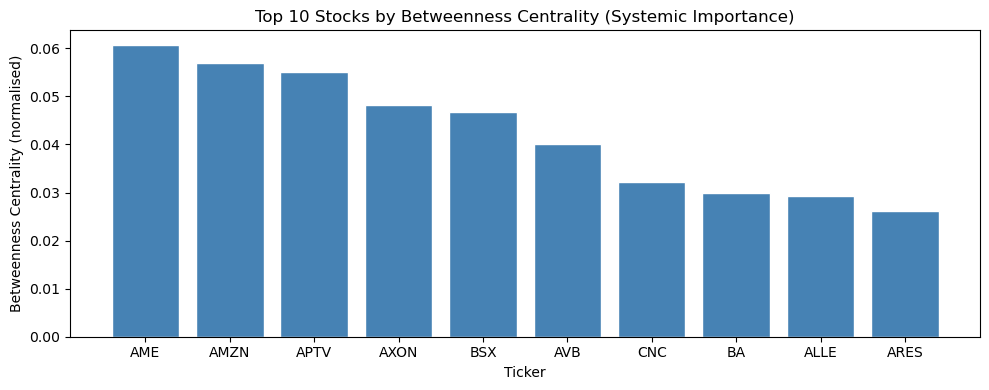

In [164]:
# Betweenness centrality — how often a node lies on shortest paths between others
betweenness = nx.betweenness_centrality(G, normalized=True)
in_deg      = dict(G.in_degree())
out_deg     = dict(G.out_degree())

# Build summary table
centrality_rows = []
for node in G.nodes():
    ticker = cols[node]
    centrality_rows.append({
        "Ticker":      ticker,
        "Sector":      sector_map.get(ticker, "Unknown"),
        "Betweenness": round(betweenness[node], 4),
        "Out-degree":  out_deg[node],
        "In-degree":   in_deg[node],
    })

centrality_df = (
    pd.DataFrame(centrality_rows)
    .sort_values("Betweenness", ascending=False)
    .reset_index(drop=True)
)

print("=" * 58)
print(f"{'Rank':<5} {'Ticker':<8} {'Betweenness':>12}  {'Out':>4}  {'In':>4}  Sector")
print("=" * 58)
for rank, row in centrality_df.head(10).iterrows():
    print(
        f"{rank+1:<5} {row['Ticker']:<8} {row['Betweenness']:>12.4f}"
        f"  {row['Out-degree']:>4}  {row['In-degree']:>4}  {row['Sector']}"
    )
print("=" * 58)

# Bar chart
fig_c, ax_c = plt.subplots(figsize=(10, 4))
top10 = centrality_df.head(10)
ax_c.bar(top10["Ticker"], top10["Betweenness"], color="steelblue", edgecolor="white")
ax_c.set_title("Top 10 Stocks by Betweenness Centrality (Systemic Importance)")
ax_c.set_ylabel("Betweenness Centrality (normalised)")
ax_c.set_xlabel("Ticker")
plt.tight_layout()
plt.show()


## Issuers At Risk: Composite Early-Warning Ranking

This table turns the GARJI filter and causal network into a practical **issuer risk monitor**.
Each issuer receives a composite score built from six components:

- current own jump probability
- current volatility stress relative to its own history
- stress coming from parent issuers in the causal graph
- in-degree as a measure of contagion vulnerability
- betweenness as a measure of systemic transmission exposure
- sector jump risk from the pooled GARJI jump block

The output includes both the **raw component values** and their **normalised score contributions**,
so the ranking is explainable rather than a black box.


Top 10 Issuers At Risk
  Ticker                  Sector        Date  RiskScore  JumpProb    VolZ  ParentStress  MaxParentJump  InDegree  OutDegree  Betweenness  SectorJumpRisk  JumpScore  VolScore  ParentScore  InDegreeScore  BetweennessScore  SectorScore        TopParents
0    AES               Utilities  2025-05-30     0.5760    0.0204  0.0132        0.0156         0.0156         1          2       0.0249          1.2251     0.4821       1.0       0.6263         0.1667            0.4096       0.8033               CNC
1   AXON             Industrials  2025-05-30     0.5331    0.0381 -0.5396        0.0111         0.0116         2          2       0.0482          1.1952     1.0000       0.0       0.4458         0.3333            0.7952       0.2884          BLK, BSX
2    AVB             Real Estate  2025-05-30     0.5293    0.0182 -0.4604        0.0182         0.0381         6          1       0.0400          1.2272     0.4175       0.0       0.7308         1.0000            0.6586     

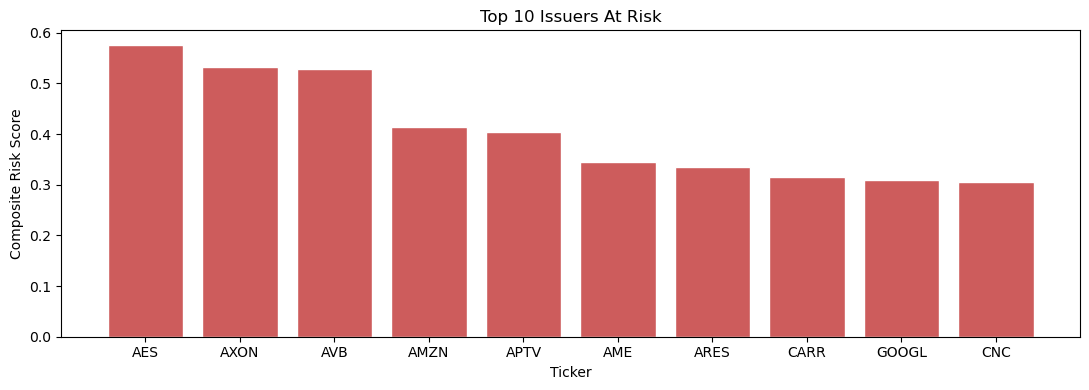

In [166]:
def minmax_scale(series):
    series = pd.Series(series, dtype=np.float64)
    finite = series.replace([np.inf, -np.inf], np.nan)
    lo = finite.min()
    hi = finite.max()
    if pd.isna(lo) or pd.isna(hi) or np.isclose(hi, lo):
        return pd.Series(0.0, index=series.index)
    return (finite - lo) / (hi - lo)


latest_date = volatilities.index[-1]
lookback = min(60, len(volatilities))
vol_window = volatilities.iloc[-lookback:]
jp_latest = jump_probs.loc[latest_date].reindex(cols).fillna(0.0)
vol_latest = volatilities.loc[latest_date].reindex(cols)
vol_mean = vol_window.mean().reindex(cols)
vol_std = vol_window.std(ddof=0).replace(0, np.nan).reindex(cols)
vol_z = ((vol_latest - vol_mean) / vol_std).replace([np.inf, -np.inf], np.nan).fillna(0.0)

sector_raw_risk = {}
for sector, pooled in sector_jump_pool.items():
    sector_raw_risk[sector] = (
        abs(pooled["mu_j"]) + pooled["sigma_j"] + pooled["phi_l"] + pooled["gamma_l"]
    )

risk_rows = []
for node in G.nodes():
    ticker = cols[node]
    sector = sector_map.get(ticker, "Unknown")
    parents = list(G.predecessors(node))
    parent_tickers = [cols[parent] for parent in parents]
    parent_jump_values = jp_latest.reindex(parent_tickers).fillna(0.0)
    parent_stress = float(parent_jump_values.mean()) if len(parent_tickers) else 0.0
    max_parent_jump = float(parent_jump_values.max()) if len(parent_tickers) else 0.0
    top_parents = ", ".join(parent_jump_values.sort_values(ascending=False).head(3).index.tolist())

    risk_rows.append({
        "Ticker": ticker,
        "Sector": sector,
        "Date": latest_date.strftime("%Y-%m-%d"),
        "JumpProb": float(jp_latest[ticker]),
        "VolZ": float(vol_z[ticker]),
        "ParentStress": parent_stress,
        "MaxParentJump": max_parent_jump,
        "InDegree": int(in_deg[node]),
        "OutDegree": int(out_deg[node]),
        "Betweenness": float(betweenness[node]),
        "SectorJumpRisk": float(sector_raw_risk.get(sector, 0.0)),
        "TopParents": top_parents if top_parents else "-",
    })

issuer_risk_df = pd.DataFrame(risk_rows)

issuer_risk_df["JumpScore"] = minmax_scale(issuer_risk_df["JumpProb"])
issuer_risk_df["VolScore"] = minmax_scale(issuer_risk_df["VolZ"].clip(lower=0.0))
issuer_risk_df["ParentScore"] = minmax_scale(issuer_risk_df["ParentStress"])
issuer_risk_df["InDegreeScore"] = minmax_scale(issuer_risk_df["InDegree"])
issuer_risk_df["BetweennessScore"] = minmax_scale(issuer_risk_df["Betweenness"])
issuer_risk_df["SectorScore"] = minmax_scale(issuer_risk_df["SectorJumpRisk"])

issuer_risk_df["RiskScore"] = (
    0.30 * issuer_risk_df["JumpScore"]
    + 0.20 * issuer_risk_df["VolScore"]
    + 0.20 * issuer_risk_df["ParentScore"]
    + 0.15 * issuer_risk_df["InDegreeScore"]
    + 0.10 * issuer_risk_df["BetweennessScore"]
    + 0.05 * issuer_risk_df["SectorScore"]
)

issuer_risk_df = issuer_risk_df.sort_values(
    ["RiskScore", "JumpProb", "ParentStress"],
    ascending=[False, False, False],
).reset_index(drop=True)

risk_display_cols = [
    "Ticker", "Sector", "Date", "RiskScore",
    "JumpProb", "VolZ", "ParentStress", "MaxParentJump",
    "InDegree", "OutDegree", "Betweenness", "SectorJumpRisk",
    "JumpScore", "VolScore", "ParentScore", "InDegreeScore",
    "BetweennessScore", "SectorScore", "TopParents",
]

risk_display = issuer_risk_df[risk_display_cols].copy()
for col in [
    "RiskScore", "JumpProb", "VolZ", "ParentStress", "MaxParentJump",
    "Betweenness", "SectorJumpRisk", "JumpScore", "VolScore",
    "ParentScore", "InDegreeScore", "BetweennessScore", "SectorScore",
]:
    risk_display[col] = risk_display[col].astype(float).round(4)

print("=" * 132)
print("Top 10 Issuers At Risk")
print("=" * 132)
print(risk_display.head(10).to_string(index=True))
print("=" * 132)

fig_r, ax_r = plt.subplots(figsize=(11, 4))
top_risk = risk_display.head(10)
ax_r.bar(top_risk["Ticker"], top_risk["RiskScore"], color="indianred", edgecolor="white")
ax_r.set_title("Top 10 Issuers At Risk")
ax_r.set_ylabel("Composite Risk Score")
ax_r.set_xlabel("Ticker")
plt.tight_layout()
plt.show()


## Out-of-Sample Backtest

Replicate the paper's warning-signal evaluation:
- Train on the first 80% of the sample.
- For each day in the test set, if a *father* node exhibits a jump probability above the threshold,
  issue a **warning** for each *son* (child) in the causal graph.
- A warning is a *true positive* if the son's volatility exceeds
  `mean_train + 1.5 × std_train` on the next day.
- Report precision = TP / (TP + FP).


In [162]:
def run_backtest(vol_df, jp_df, adj_mat, ticker_cols,
                 train_frac=0.8, jump_thr=0.5, vol_z=1.5):
    """
    Out-of-sample backtest following the paper's father/son warning protocol.
    Father node: emits a warning when jump_prob > jump_thr.
    Warning: son will have elevated volatility on the next period.
    """
    total_obs = len(vol_df)
    train_size = int(total_obs * train_frac)

    vol_train = vol_df.iloc[:train_size]
    vol_test = vol_df.iloc[train_size:]
    jp_test = jp_df.loc[vol_test.index]

    thresholds = vol_train.mean() + vol_z * vol_train.std()
    graph_bt = nx.from_numpy_array(adj_mat, create_using=nx.DiGraph())

    true_positives = 0
    false_positives = 0
    warnings_issued = 0
    dates = vol_test.index

    for t in range(1, len(dates)):
        prev_date, curr_date = dates[t - 1], dates[t]
        for parent_idx, ticker in enumerate(ticker_cols):
            if jp_test.loc[prev_date, ticker] < jump_thr:
                continue

            for child_idx in graph_bt.successors(parent_idx):
                child_ticker = ticker_cols[child_idx]
                warnings_issued += 1
                if vol_test.loc[curr_date, child_ticker] > thresholds[child_ticker]:
                    true_positives += 1
                else:
                    false_positives += 1

    precision = true_positives / max(warnings_issued, 1)
    recall_denominator = max(int((vol_test > thresholds).values.sum()), 1)
    recall = true_positives / recall_denominator

    return {
        "warnings": warnings_issued,
        "TP": true_positives,
        "FP": false_positives,
        "precision": precision,
        "recall": recall,
        "train_end": vol_df.index[train_size - 1].strftime("%Y-%m-%d"),
        "test_start": vol_df.index[train_size].strftime("%Y-%m-%d"),
    }


print("Running out-of-sample backtest ...")
bt = run_backtest(volatilities, jump_probs, adj_matrix, cols,
                  train_frac=0.8, jump_thr=0.5, vol_z=1.5)

print(f"\n{'=' * 40}")
print(f"Backtest results (train through {bt['train_end']}, test from {bt['test_start']})")
print(f"{'=' * 40}")
print(f"  Warnings issued : {bt['warnings']}")
print(f"  True positives  : {bt['TP']}")
print(f"  False positives : {bt['FP']}")
print(f"  Precision       : {bt['precision']:.3f}")
print(f"  Recall (approx) : {bt['recall']:.3f}")


Running out-of-sample backtest ...

Backtest results (train through 2025-01-03, test from 2025-01-06)
  Warnings issued : 145
  True positives  : 52
  False positives : 93
  Precision       : 0.359
  Recall (approx) : 0.213


## Visualize the Causal Network

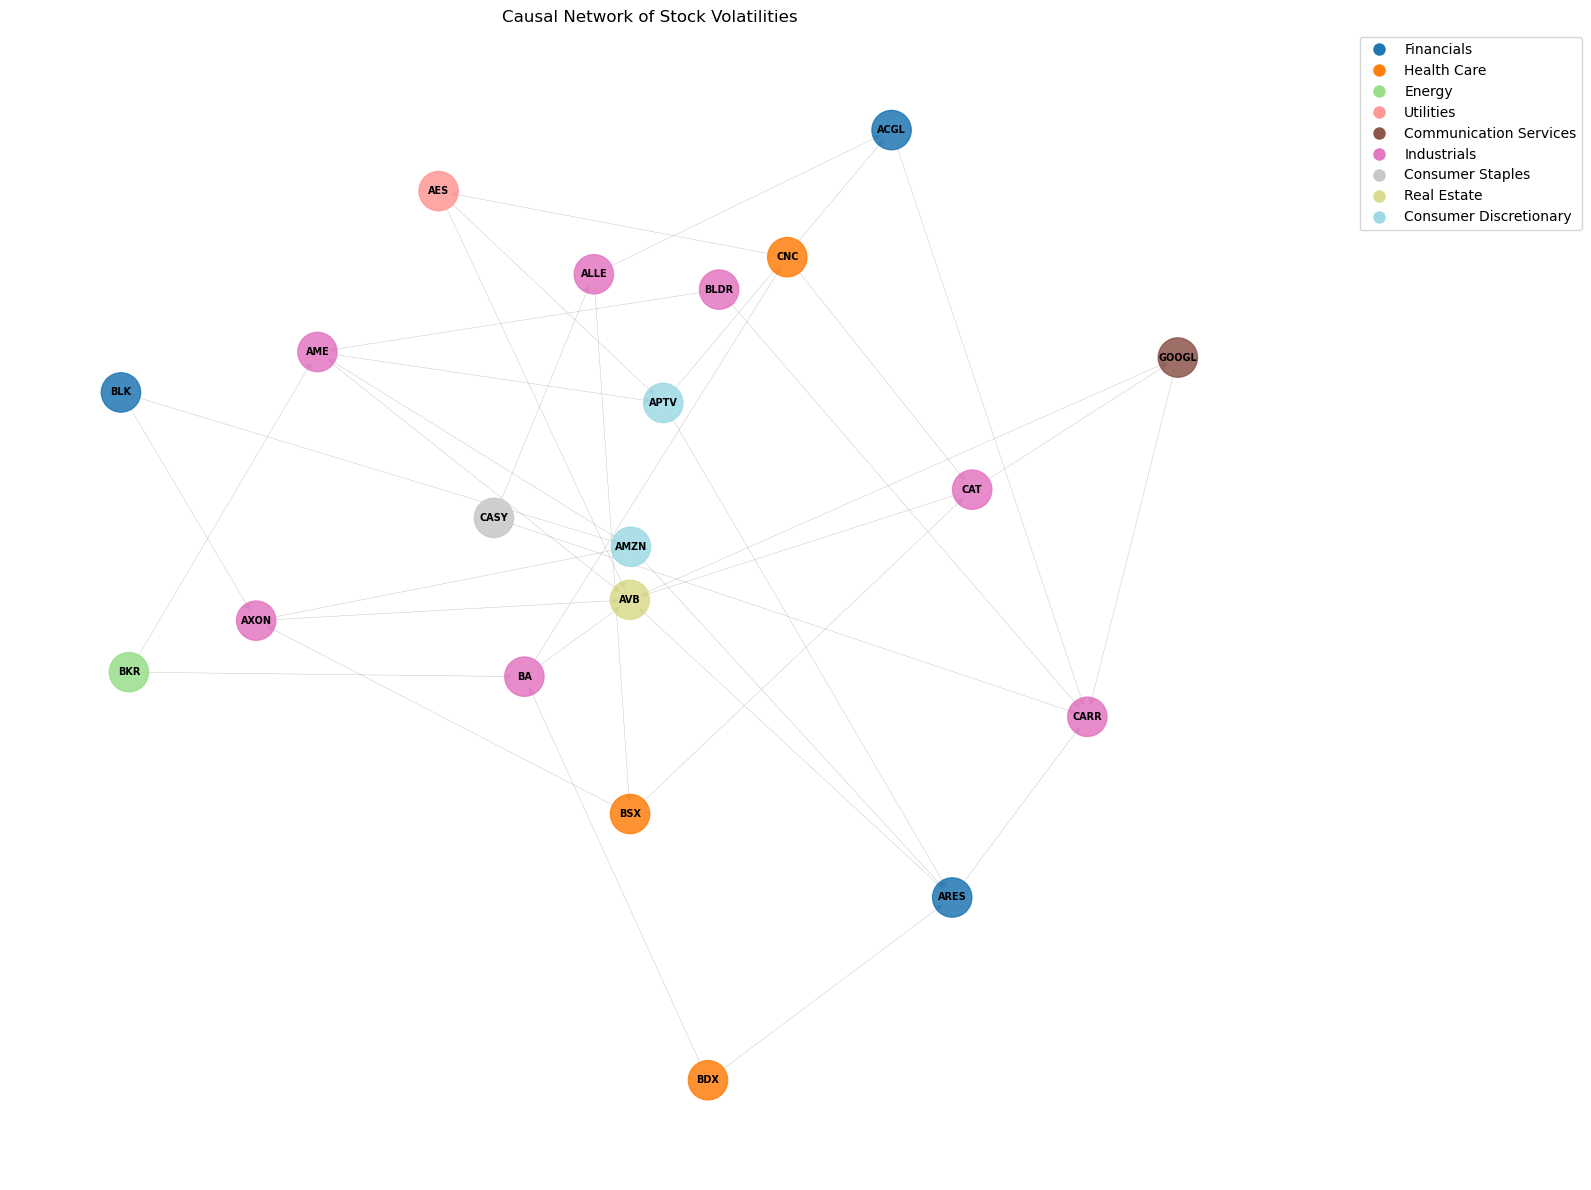

In [163]:
plt.figure(figsize=(16, 12))
sectors = set(nx.get_node_attributes(G, 'sector').values())
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
color_map = {sector: palette[i] for i, sector in enumerate(sectors)}
node_colors = [color_map[G.nodes[n]['sector']] for n in G.nodes()]
pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw_networkx_edges(G, pos, edge_color='gray', width=0.3, alpha=0.5, arrows=True)
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors, alpha=0.85)

labels = {n: G.nodes[n]['ticker'] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, font_weight='bold')

patches = [
    plt.Line2D([0], [0], marker='o', color='w',
              markerfacecolor=color_map[s], markersize=10, label=s)
    for s in sectors
]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Causal Network of Stock Volatilities")
plt.axis('off')
plt.tight_layout()
plt.show()
